## 1. Drive'ı bağla ve repo klasörüne gir

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/SynDataGen/models/RS-paint


/content/drive/.shortcut-targets-by-id/1qW2CVvnw_L-G4Gb2oBNdqjYnP62j_EzG/private-bdi/models/RS-paint


## 2. RS-Paint repo kurulumu (tek seferlik — klasor zaten doluysa atla)

In [ ]:
import os
if not os.path.isdir('ldm'):
    !git clone https://github.com/SteveImmanuel/rs-paint.git tmp_repo
    !mv tmp_repo/* tmp_repo/.[!.]* . 2>/dev/null
    !rmdir tmp_repo
else:
    print('Repo zaten kurulu, klonlamaya gerek yok.')


In [3]:
!ls -la


total 109
drwx------ 2 root root  4096 Jul 14 10:56 checkpoints
drwx------ 2 root root  4096 Jul 14 10:53 configs
-rw------- 1 root root  7374 Jul 14 10:53 environment.yaml
drwx------ 2 root root  4096 Jul 14 10:53 eval_tool
drwx------ 2 root root  4096 Jul 14 10:53 figure
-rw------- 1 root root  3495 Jul 14 10:53 .gitignore
-rw------- 1 root root   148 Jul 14 10:53 inference_test_bench.sh
drwx------ 2 root root  4096 Jul 14 10:53 ldm
-rw------- 1 root root 11356 Jul 14 10:53 LICENSE
-rw------- 1 root root 27105 Jul 14 10:53 main.py
drwx------ 2 root root  4096 Jul 14 10:53 notebooks
-rw------- 1 root root  5147 Jul 14 10:53 README.md
-rw------- 1 root root 13296 Jul 14 13:44 RS-Paint_Pipeline.ipynb
-rw------- 1 root root  6320 Jul 14 11:48 run_rspaint_single.py
drwx------ 2 root root  4096 Jul 14 10:53 scripts
-rw------- 1 root root   233 Jul 14 10:53 setup.py
drwx------ 2 root root  4096 Jul 14 10:53 test_bench
-rw------- 1 root root   832 Jul 14 10:53 test.sh
-rw------- 1 root root 

## 3. Checkpoint indirme (tek seferlik — dosyalar Drive'da kalıcı)

In [4]:
import os
os.makedirs('checkpoints', exist_ok=True)

if not os.path.exists('checkpoints/sd_inpaint_samrs_ep74.ckpt'):
    !wget -O checkpoints/sd_inpaint_samrs_ep74.ckpt "https://huggingface.co/SteveImmanuel/RSPaint/resolve/main/sd_inpaint_samrs_ep74.ckpt"
else:
    print('sd_inpaint_samrs_ep74.ckpt zaten var.')

if not os.path.exists('checkpoints/remoteclip.pt'):
    # NOT: normal wget xet-CDN yonlendirmesinde bazen 403/kucuk-hata-govdesi donuyor,
    # ?download=true + retry ile calisan versiyon bu
    !curl -L --retry 5 --retry-delay 5 -A "Mozilla/5.0" \
        -o checkpoints/remoteclip.pt \
        "https://huggingface.co/SteveImmanuel/RSPaint/resolve/main/remoteclip.pt?download=true"
else:
    print('remoteclip.pt zaten var.')


sd_inpaint_samrs_ep74.ckpt zaten var.
remoteclip.pt zaten var.


In [5]:
!ls -lh checkpoints/


total 6.5G
-rw------- 1 root root 1.6G Jul 14 11:32 remoteclip.pt
-rw------- 1 root root 4.9G Jul 14 10:56 sd_inpaint_samrs_ep74.ckpt


## 4. Python paketleri
`pytorch-lightning`'in GUNCEL surumunu kuruyoruz (eski 1.4.2 pin'i torchmetrics ile cakisiyordu).
**Bu hucreden sonra Runtime > Restart session gerekebilir** eger pytorch_lightning bu oturumda daha once import edildiyse.

In [3]:
!pip install -q -U pytorch-lightning omegaconf einops open_clip_torch
!pip install -q git+https://github.com/CompVis/taming-transformers.git


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [4]:
!pip show pytorch-lightning | grep Version
# 2.x gibi guncel bir surum gormen lazim; hala eski (1.4.2) gorunuyorsa Runtime > Restart session yap
# ve Drive mount + %cd hucrelerini tekrar calistirdiktan sonra bu hucreye geri don.


Version: 2.6.5


In [8]:
!pip install git+https://github.com/CompVis/taming-transformers.git

  Cloning https://github.com/CompVis/taming-transformers.git to /tmp/pip-req-build-hg3wpld5
  Running command git clone --filter=blob:none --quiet https://github.com/CompVis/taming-transformers.git /tmp/pip-req-build-hg3wpld5
  Resolved https://github.com/CompVis/taming-transformers.git to commit 3ba01b241669f5ade541ce990f7650a3b8f65318
  Preparing metadata (setup.py) ... done


In [4]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "GPU YOK")

2.11.0+cu128
True
NVIDIA A100-SXM4-40GB


In [5]:
!nvidia-smi

Tue Jul 14 14:05:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             44W /  400W |       6MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
!pip install -q -U pytorch-lightning omegaconf einops open_clip_torch
!pip install -q taming-transformers-rom1504

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.5 MB/s eta 0:00:00


In [6]:
!python -c "from taming.modules.vqvae.quantize import VectorQuantizer2; print('taming OK')"
!pip show pytorch-lightning | grep Version

taming OK
Version: 2.6.5


## 5. Eski API uyumluluk yaması (tek seferlik dosya değişikliği)
`ldm/models/diffusion/ddpm.py` eski `pytorch_lightning.utilities.distributed` yolunu kullaniyor, guncel surumde bu `utilities.rank_zero`'ya tasindi. Sadece import satirini duzeltiyoruz, davranis degismiyor.

In [3]:
!grep -n "rank_zero_only" ldm/models/diffusion/ddpm.py


19:from pytorch_lightning.utilities.rank_zero import rank_zero_only
495:    @rank_zero_only


In [4]:
!sed -i 's/from pytorch_lightning.utilities.distributed import rank_zero_only/from pytorch_lightning.utilities.rank_zero import rank_zero_only/' ldm/models/diffusion/ddpm.py
!grep -n "rank_zero_only" ldm/models/diffusion/ddpm.py
# ilk satirin 'utilities.rank_zero' olarak degistigini dogrula


19:from pytorch_lightning.utilities.rank_zero import rank_zero_only
495:    @rank_zero_only


## 6. `run_rspaint_single.py` dosyasını yaz

In [11]:
%%writefile run_rspaint_single.py
"""
run_rspaint_single.py
======================
run_harmonidiff_single.py'nin RS-Paint'e UYARLANMIS hali. Ayni instance
klasor yapisini (bg.png / mask_location.png / fg.png / meta.json) okur,
sadece MODEL COGRISI HarmoniDiff yerine RS-Paint (Paint-by-Example tabanli
Stable Diffusion inpainting + RemoteCLIP) olur.

ORTAK KALAN KISIMLAR (run_harmonidiff_single.py ile ayni mantik):
  - load_instance(): bg/mask/fg/meta okuma
  - CLI arg yapisi: --synthetic_dir, --out_dir, --instances
  - instance basina cikti klasoru + meta.json kopyalama

DEGISEN KISIMLAR (RS-Paint'e ozgu):
  - enrich_meta.py alanlarina (bg_prompt/fg_prompt/lon/lat/gsd/tarih) IHTIYAC YOK.
    RS-Paint metin/metadata kosullamasi kullanmiyor, sadece goruntu + CLIP embedding.
  - fg.png, HarmoniDiff'teki gibi bbox boyutuna degil, RS-Paint'in bekledigi
    224x224'e resize edilip CLIP-normalize ediliyor (ref_tensor).
  - mask_location.png ayni "255=inpaint edilecek yer" semantigini tasiyor,
    ama RS-Paint kodu iceride mask = 1 - mask/255 seklinde TERSINE ceviriyor
    (bkz. generate_samples.ipynb) - bunu tekrar yapmiyoruz, olay ldm tarafinda
    hallediliyor, sadece dogru mask_path'i veriyoruz.
  - n_samples uretilip RemoteCLIP cosine-similarity'e gore EN IYI ornek seciliyor
    (HarmoniDiff'te tek sonuc donuyordu).
  - Opsiyonel SAM mask refinement adimi eklendi (--refine_mask).

BU SCRIPT rs-paint REPO KOKUNDEN calistirilmali (ldm.*, segment_anything
relative/kurulu paketler uzerinden import ediliyor):
    cd rs-paint
    python run_rspaint_single.py \
        --synthetic_dir /content/drive/MyDrive/SAR/SynDataGen/outputs/synthetic_pairs \
        --out_dir /content/drive/MyDrive/SAR/SynDataGen/outputs/rspaint_results \
        --instances turkey-earthquake_00001030_inst0001 turkey-earthquake_00000933_inst0001
"""
import argparse
import json
import os
import shutil

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from omegaconf import OmegaConf
from PIL import Image
from pytorch_lightning import seed_everything
from torchvision.transforms import Resize

from ldm.util import instantiate_from_config
from ldm.models.diffusion.plms import PLMSSampler


# --- ORTAK: run_harmonidiff_single.py'deki load_instance ile ayni ---
def load_instance(inst_dir):
    bg = Image.open(os.path.join(inst_dir, "bg.png")).convert("RGB")
    mask = Image.open(os.path.join(inst_dir, "mask_location.png")).convert("L")
    fg = Image.open(os.path.join(inst_dir, "fg.png")).convert("RGB")
    with open(os.path.join(inst_dir, "meta.json")) as f:
        meta = json.load(f)
    return bg, mask, fg, meta


def load_model_from_config(config, ckpt, device):
    print(f"Model yukleniyor: {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    model.load_state_dict(sd, strict=False)
    model = model.to(device)
    model.eval()
    return model


def get_tensor():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])


def get_tensor_clip():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                                          (0.26862954, 0.26130258, 0.27577711)),
    ])


@torch.inference_mode()
def rspaint_generate(model, sampler, bg_img, mask_img, ref_img, scale, ddim_steps, n_samples, device):
    """generate_samples() (notebooks/generate_samples.ipynb) ile ayni mantik,
    dosya yolu yerine PIL image alacak sekilde ufak degisiklik."""
    img_p = bg_img.resize((512, 512))
    image_tensor = get_tensor()(img_p).unsqueeze(0).repeat(n_samples, 1, 1, 1).to(device)

    # DEGISTI: fg 224x224'e resize + CLIP-normalize (bbox boyutuna resize YOK)
    ref_p = ref_img.resize((224, 224))
    ref_tensor = get_tensor_clip()(ref_p).unsqueeze(0).repeat(n_samples, 1, 1, 1).to(device)

    mask = np.array(mask_img.resize((512, 512), Image.NEAREST))[None, None]
    mask = 1 - mask.astype(np.float32) / 255.0  # 255(inpaint edilecek yer) -> 0
    mask[mask < 0.5] = 0
    mask[mask >= 0.5] = 1
    mask_tensor = torch.from_numpy(mask).repeat(n_samples, 1, 1, 1).to(device)

    uc = model.learnable_vector.repeat(n_samples, 1, 1) if scale != 1.0 else None
    c = model.proj_out(model.get_learned_conditioning(ref_tensor))

    inpaint_image = image_tensor * mask_tensor
    z_inpaint = model.get_first_stage_encoding(model.encode_first_stage(inpaint_image)).detach()
    test_model_kwargs = {
        "inpaint_image": z_inpaint,
        "inpaint_mask": Resize([z_inpaint.shape[-2], z_inpaint.shape[-1]])(mask_tensor),
    }

    samples_ddim, _ = sampler.sample(
        S=ddim_steps, conditioning=c, batch_size=n_samples, shape=[4, 64, 64],
        verbose=False, unconditional_guidance_scale=scale, unconditional_conditioning=uc,
        eta=0.0, x_T=None, test_model_kwargs=test_model_kwargs,
    )
    x = model.decode_first_stage(samples_ddim)
    x = torch.clamp((x + 1.0) / 2.0, min=0.0, max=1.0)
    return x.cpu().permute(0, 2, 3, 1).numpy()


def pick_best_sample(model, samples, ref_img, device):
    """DEGISTI: HarmoniDiff tek sonuc donuyordu, RS-Paint n_samples uretip
    RemoteCLIP cosine-similarity'e gore en iyisini seciyor (orijinal notebook mantigi)."""
    img_preprocessor = model.cond_stage_model.preprocess
    ref_feat = model.cond_stage_model.get_visual_clip_features(
        img_preprocessor(ref_img).unsqueeze(0).to(device)
    )
    best_idx, best_score = 0, -1.0
    for i in range(len(samples)):
        result = Image.fromarray((samples[i] * 255).astype(np.uint8))
        result_feat = model.cond_stage_model.get_visual_clip_features(
            img_preprocessor(result).unsqueeze(0).to(device)
        )
        score = F.cosine_similarity(ref_feat, result_feat, dim=-1).item()
        if score > best_score:
            best_score, best_idx = score, i
    return best_idx, best_score


def harmonize_one_rspaint(model, sampler, inst_dir, out_dir, scale, ddim_steps, n_samples, device):
    bg, mask, fg, meta = load_instance(inst_dir)
    # DEGISTI: enrich_meta.py alanlari (bg_prompt/fg_prompt/lon/lat/gsd/tarih) BURADA GEREKMIYOR

    samples = rspaint_generate(model, sampler, bg, mask, fg, scale, ddim_steps, n_samples, device)
    best_idx, best_score = pick_best_sample(model, samples, fg, device)
    result_raw_img = Image.fromarray((samples[best_idx] * 255).astype(np.uint8)).resize(bg.size)

    # --- EKLENDI: run_harmonidiff_single.py ile AYNI post-process mantigi ---
    # RS-Paint tum 512x512 canvas'i VAE'den gecirip yeniden uretiyor, bu yuzden
    # mask DISINDA bile SAR speckle dokusunda kucuk-ama-yaygin fark olusuyor
    # (VAE reconstruction gurultusu). Change detection icin bu kabul edilemez:
    # target etiketi sadece maskeli bolgeyi "degisti" diyor, bu yuzden pre/post
    # farki da SADECE o bolgede olmali. Mask disini orijinal bg'ye geri donduruyoruz.
    mask_resized = mask.resize(bg.size, resample=Image.NEAREST)
    mask_arr = (np.array(mask_resized) > 127).astype(np.float32)[..., None]
    result_arr = np.array(result_raw_img.convert("RGB")).astype(np.float32)
    bg_arr = np.array(bg.convert("RGB")).astype(np.float32)
    final_arr = (mask_arr * result_arr + (1 - mask_arr) * bg_arr).astype(np.uint8)
    final_img = Image.fromarray(final_arr)

    # --- ORTAK: run_harmonidiff_single.py ile ayni cikti disiplini ---
    inst_name = os.path.basename(inst_dir.rstrip("/"))
    inst_out_dir = os.path.join(out_dir, inst_name)
    os.makedirs(inst_out_dir, exist_ok=True)
    result_raw_img.save(os.path.join(inst_out_dir, "result_raw.png"))   # ham (VAE gurultulu) cikti
    final_img.save(os.path.join(inst_out_dir, "result.png"))            # NIHAI (mask-disi korunmus) cikti
    shutil.copy(os.path.join(inst_dir, "meta.json"), os.path.join(inst_out_dir, "meta.json"))
    with open(os.path.join(inst_out_dir, "clip_similarity.txt"), "w") as f:
        f.write(f"best_sample_idx={best_idx}\nclip_cosine_similarity={best_score:.5f}\n")

    print(f"OK: {inst_name} -> {inst_out_dir}/result.png (clip_sim={best_score:.4f})")
    return inst_out_dir


def main():
    parser = argparse.ArgumentParser()
    # --- ORTAK: run_harmonidiff_single.py ile ayni CLI arayuzu ---
    parser.add_argument("--synthetic_dir", type=str, required=True)
    parser.add_argument("--out_dir", type=str, required=True)
    parser.add_argument("--instances", type=str, nargs="+", required=True)
    # --- DEGISTI: RS-Paint'e ozgu argumanlar ---
    parser.add_argument("--config_path", type=str, default="configs/rs_remoteclip.yaml")
    parser.add_argument("--ckpt_path", type=str, default="checkpoints/sd_inpaint_samrs_ep74.ckpt")
    parser.add_argument("--scale", type=float, default=8.0, help="classifier-free guidance scale")
    parser.add_argument("--ddim_steps", type=int, default=50)
    parser.add_argument("--n_samples", type=int, default=4, help="RemoteCLIP ile en iyisi secilecek aday sayisi")
    parser.add_argument("--seed", type=int, default=20250110)
    args = parser.parse_args()

    os.makedirs(args.out_dir, exist_ok=True)
    seed_everything(args.seed)
    device = 0 if torch.cuda.is_available() else "cpu"

    config = OmegaConf.load(args.config_path)
    model = load_model_from_config(config, args.ckpt_path, device)
    sampler = PLMSSampler(model)
    print("Model hazir.")

    for inst_name in args.instances:
        inst_dir = os.path.join(args.synthetic_dir, inst_name)
        if not os.path.isdir(inst_dir):
            print(f"UYARI: klasor bulunamadi, atlaniyor: {inst_dir}")
            continue
        try:
            harmonize_one_rspaint(model, sampler, inst_dir, args.out_dir,
                                   args.scale, args.ddim_steps, args.n_samples, device)
        except Exception as e:
            print(f"HATA - {inst_name}: {e}")


if __name__ == "__main__":
    main()


Overwriting run_rspaint_single.py


In [6]:
!wc -l run_rspaint_single.py
!tail -5 run_rspaint_single.py
# tail ciktisinda 'if __name__ == "__main__":' ve 'main()' gorunmeli


159 run_rspaint_single.py
            print(f"HATA - {inst_name}: {e}")


if __name__ == "__main__":
    main()


## 7. Test çalıştırma (tek instance)

In [9]:
import subprocess
result = subprocess.run(
    ["python", "run_rspaint_single.py",
     "--synthetic_dir", "/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs",
     "--out_dir", "/content/drive/MyDrive/SynDataGen/outputs/rspaint_results",
     "--instances", "haiti-earthquake_00000000_inst0001"],
    capture_output=True, text=True
)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("RETURN CODE:", result.returncode)


STDOUT:
 Model yukleniyor: checkpoints/sd_inpaint_samrs_ep74.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model hazir.
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
OK: haiti-earthquake_00000000_inst0001 -> /content/drive/MyDrive/SynDataGen/outputs/rspaint_results/haiti-earthquake_00000000_inst0001/result_raw.png (clip_sim=0.8580)

STDERR:
 Seed set to 20250110

PLMS Sampler: 100%|██████████| 50/50 [00:17<00:00,  2.80it/s]

RETURN CODE: 0


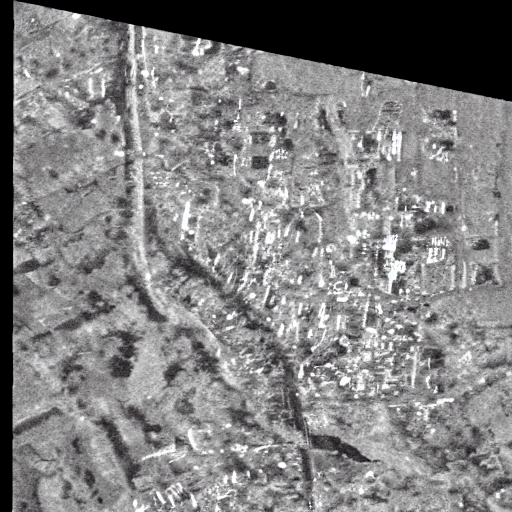

In [10]:
from PIL import Image
img = Image.open("/content/drive/MyDrive/SynDataGen/outputs/rspaint_results/haiti-earthquake_00000000_inst0001/result_raw.png")
img

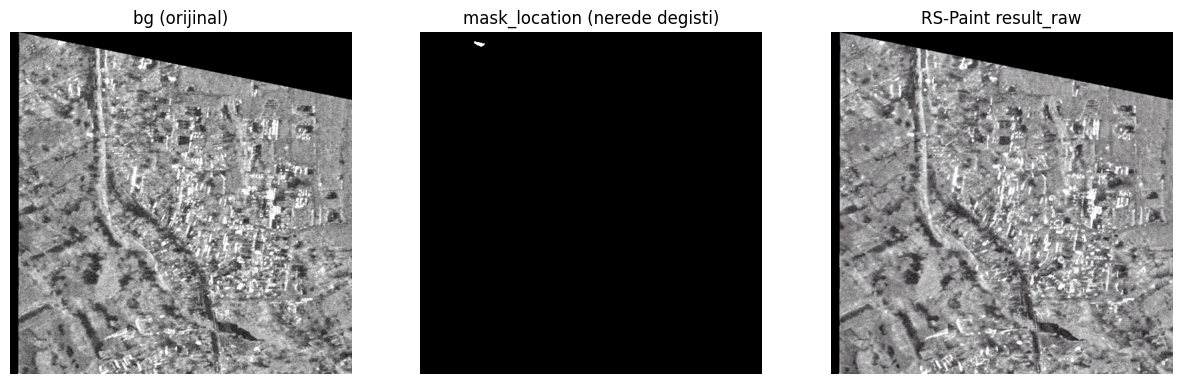

In [11]:
import matplotlib.pyplot as plt
from PIL import Image

inst_dir = "/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs/haiti-earthquake_00000000_inst0001"
out_dir = "/content/drive/MyDrive/SynDataGen/outputs/rspaint_results/haiti-earthquake_00000000_inst0001"

bg = Image.open(f"{inst_dir}/bg.png")
mask = Image.open(f"{inst_dir}/mask_location.png")
result = Image.open(f"{out_dir}/result_raw.png")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(bg); axes[0].set_title("bg (orijinal)"); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title("mask_location (nerede degisti)"); axes[1].axis('off')
axes[2].imshow(result); axes[2].set_title("RS-Paint result_raw"); axes[2].axis('off')
plt.show()

{'scene_id': 'haiti-earthquake_00000000', 'instance_id': 1, 'bbox_px': [163, 28, 195, 46], 'xy_normalized': [0.1591796875, 0.02734375], 'wh_normalized': [0.03125, 0.017578125], 'instance_area_px': 284, 'matched_crop_area_px': 284, 'area_diff_px': 0, 'damage_class': 3, 'class_name': 'destroyed', 'source_crop': '/content/drive/MyDrive/SAR/SynDataGen/data/damagedbuildings/congo-volcano_00000055_bldg0018_destroyed.png', 'country': 'Haiti', 'longitude': -73.8, 'latitude': 18.4, 'bg_gsd': 0.48, 'fg_gsd': 0.48, 'cloud_cover': 0.0, 'year': 2021, 'month': 8, 'day': 14, 'bg_prompt': 'a SAR satellite image of buildings after an earthquake in Haiti', 'fg_prompt': 'a SAR satellite image of a destroyed building after an earthquake in Haiti'}
crop box: 61 0 117 43


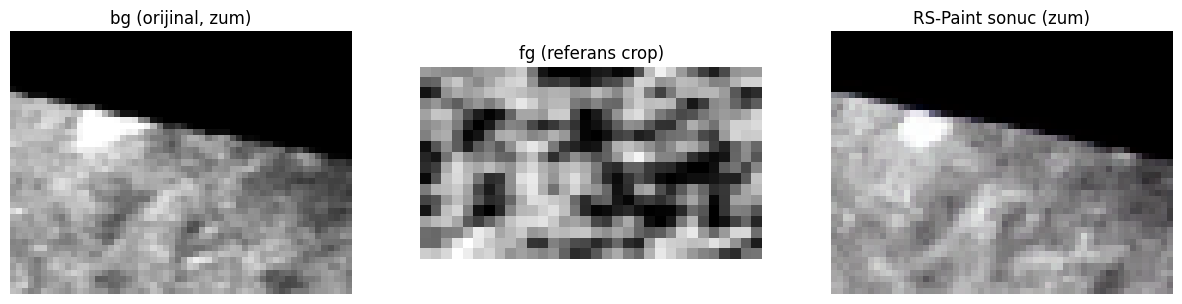

In [12]:
import json
import matplotlib.pyplot as plt
from PIL import Image

inst_dir = "/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs/haiti-earthquake_00000000_inst0001"
out_dir = "/content/drive/MyDrive/SynDataGen/outputs/rspaint_results/haiti-earthquake_00000000_inst0001"

with open(f"{inst_dir}/meta.json") as f:
    meta = json.load(f)
print(meta)

bg = Image.open(f"{inst_dir}/bg.png")
result = Image.open(f"{out_dir}/result_raw.png")
fg = Image.open(f"{inst_dir}/fg.png")

# xy_normalized ve wh_normalized 512x512 canvas'a gore, biraz pay birakarak kirp
px, py = meta["xy_normalized"]
pw, ph = meta["wh_normalized"]
W = H = 512
pad = 20
x1 = max(0, int(px*W) - pad)
y1 = max(0, int(py*H) - pad)
x2 = min(W, int((px+pw)*W) + pad)
y2 = min(H, int((py+ph)*H) + pad)
print("crop box:", x1, y1, x2, y2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(bg.crop((x1,y1,x2,y2))); axes[0].set_title("bg (orijinal, zum)"); axes[0].axis('off')
axes[1].imshow(fg); axes[1].set_title("fg (referans crop)"); axes[1].axis('off')
axes[2].imshow(result.crop((x1,y1,x2,y2))); axes[2].set_title("RS-Paint sonuc (zum)"); axes[2].axis('off')
plt.show()

In [13]:
import os, json

synth_dir = "/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs"
areas = []
for d in os.listdir(synth_dir):
    meta_path = os.path.join(synth_dir, d, "meta.json")
    if os.path.exists(meta_path):
        with open(meta_path) as f:
            m = json.load(f)
        area = m.get("instance_area_px", m.get("area_px", 0))
        areas.append((area, d))

areas.sort(reverse=True)
print("En buyuk 10 instance:")
for area, d in areas[:10]:
    print(f"{area:>8} px  -  {d}")

En buyuk 10 instance:
   21590 px  -  turkey-earthquake_00000602_inst0002
   20754 px  -  morocco-earthquake_00000354_inst0001
   18092 px  -  turkey-earthquake_00000683_inst0001
   15491 px  -  turkey-earthquake_00000556_inst0001
   13363 px  -  turkey-earthquake_00000797_inst0001
   12667 px  -  turkey-earthquake_00001065_inst0001
   11284 px  -  turkey-earthquake_00001076_inst0001
   11003 px  -  turkey-earthquake_00000417_inst0001
   10717 px  -  turkey-earthquake_00000559_inst0001
   10361 px  -  turkey-earthquake_00000374_inst0001


In [14]:
#en büyük instance ile deneme
import subprocess
result = subprocess.run(
    ["python", "run_rspaint_single.py",
     "--synthetic_dir", "/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs",
     "--out_dir", "/content/drive/MyDrive/SynDataGen/outputs/rspaint_results",
     "--instances", "turkey-earthquake_00000602_inst0002"],
    capture_output=True, text=True
)
print("STDOUT:\n", result.stdout)
print("STDERR (son kisim):\n", result.stderr[-1000:])
print("RETURN CODE:", result.returncode)

STDOUT:
 Model yukleniyor: checkpoints/sd_inpaint_samrs_ep74.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model hazir.
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
OK: turkey-earthquake_00000602_inst0002 -> /content/drive/MyDrive/SynDataGen/outputs/rspaint_results/turkey-earthquake_00000602_inst0002/result_raw.png (clip_sim=0.8205)

STDERR (son kisim):
 87it/s]
PLMS Sampler: 100%|██████████| 50/50 [00:17<00:00,  2.81it/s]

RETURN CODE: 0


{'scene_id': 'turkey-earthquake_00000602', 'instance_id': 2, 'bbox_px': [456, 0, 692, 189], 'xy_normalized': [0.4453125, 0.0], 'wh_normalized': [0.23046875, 0.1845703125], 'instance_area_px': 21590, 'matched_crop_area_px': 21590, 'area_diff_px': 0, 'damage_class': 3, 'class_name': 'destroyed', 'source_crop': '/content/drive/MyDrive/SAR/SynDataGen/data/damagedbuildings/la_palma-volcano_00000454_bldg0005_destroyed.png', 'country': 'Turkey', 'longitude': 37.0, 'latitude': 37.2, 'bg_gsd': 0.325, 'fg_gsd': 0.325, 'cloud_cover': 0.0, 'year': 2023, 'month': 2, 'day': 6, 'bg_prompt': 'a SAR satellite image of buildings after an earthquake in Turkey', 'fg_prompt': 'a SAR satellite image of a destroyed building after an earthquake in Turkey'}


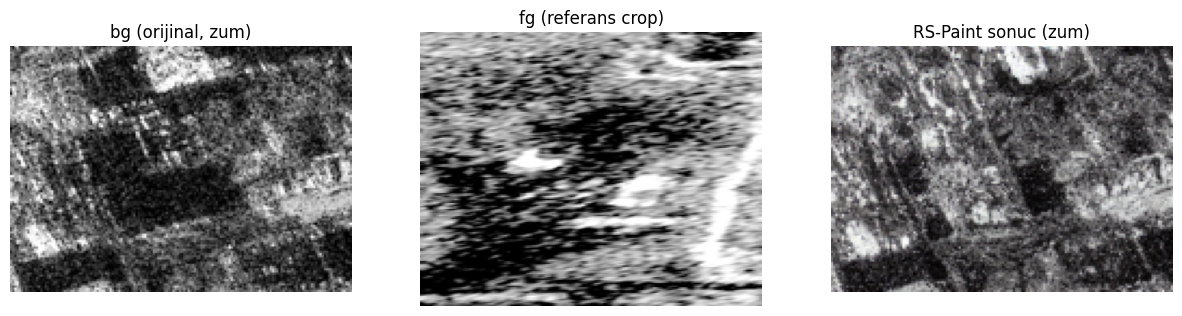

In [15]:
import json
import matplotlib.pyplot as plt
from PIL import Image

inst_name = "turkey-earthquake_00000602_inst0002"
inst_dir = f"/content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs/{inst_name}"
out_dir = f"/content/drive/MyDrive/SynDataGen/outputs/rspaint_results/{inst_name}"

with open(f"{inst_dir}/meta.json") as f:
    meta = json.load(f)
print(meta)

bg = Image.open(f"{inst_dir}/bg.png")
result = Image.open(f"{out_dir}/result_raw.png")
fg = Image.open(f"{inst_dir}/fg.png")

px, py = meta["xy_normalized"]
pw, ph = meta["wh_normalized"]
W = H = 512
pad = 20
x1 = max(0, int(px*W) - pad)
y1 = max(0, int(py*H) - pad)
x2 = min(W, int((px+pw)*W) + pad)
y2 = min(H, int((py+ph)*H) + pad)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(bg.crop((x1,y1,x2,y2))); axes[0].set_title("bg (orijinal, zum)"); axes[0].axis('off')
axes[1].imshow(fg); axes[1].set_title("fg (referans crop)"); axes[1].axis('off')
axes[2].imshow(result.crop((x1,y1,x2,y2))); axes[2].set_title("RS-Paint sonuc (zum)"); axes[2].axis('off')
plt.show()

In [12]:
%%writefile run_rspaint_batch.py
"""
run_rspaint_batch.py
=====================
run_rspaint_single.py'nin TOPLU (batch) hali. --instances ile tek tek isim
vermek yerine, --synthetic_dir altindaki TUM instance klasorlerini bulup
sirayla isler. Model SADECE BIR KEZ yuklenir (tekil script'te de boyleydi,
ama tekil script'i N kere cagirirsan model N kere yuklenir - bu, GPU'ya
gereksiz tekrar yukleme yapmadan hepsini isler).

OZELLIKLER:
  - Zaten islenmis (out_dir'da result.png'si olan) instance'lari ATLAR
    -> Colab kopup tekrar baslatirsan kaldigin yerden devam eder (resume).
  - Eksik dosyali (bg.png/mask_location.png/fg.png/meta.json yok) klasorleri
    atlar, hata vermez.
  - Her instance ayri try/except -> biri patlarsa butun batch durmaz,
    hatalar sonunda ozetlenir.
  - --limit ile once kucuk bir alt kumede test etmeni saglar.
  - --shuffle ile rastgele siraya sokar (COK BUYUK setlerde ilk N'i degil
    cesitli sahnelerden ornek gormek icin faydali).

Kullanim (rs-paint repo kokunden):
    python run_rspaint_batch.py \
        --synthetic_dir /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs \
        --out_dir /content/drive/MyDrive/SynDataGen/outputs/rspaint_results \
        --limit 20              # once 20 tanesiyle test et
        # --limit vermezsen TUMUNU isler
"""
import argparse
import json
import os
import random
import shutil
import time

import numpy as np
import torch
import torch.nn.functional as F
import torchvision
from omegaconf import OmegaConf
from PIL import Image
from pytorch_lightning import seed_everything
from torchvision.transforms import Resize

from ldm.util import instantiate_from_config
from ldm.models.diffusion.plms import PLMSSampler


def load_instance(inst_dir):
    bg = Image.open(os.path.join(inst_dir, "bg.png")).convert("RGB")
    mask = Image.open(os.path.join(inst_dir, "mask_location.png")).convert("L")
    fg = Image.open(os.path.join(inst_dir, "fg.png")).convert("RGB")
    with open(os.path.join(inst_dir, "meta.json")) as f:
        meta = json.load(f)
    return bg, mask, fg, meta


def load_model_from_config(config, ckpt, device):
    print(f"Model yukleniyor: {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    model.load_state_dict(sd, strict=False)
    model = model.to(device)
    model.eval()
    return model


def get_tensor():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])


def get_tensor_clip():
    return torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.48145466, 0.4578275, 0.40821073),
                                          (0.26862954, 0.26130258, 0.27577711)),
    ])


@torch.inference_mode()
def rspaint_generate(model, sampler, bg_img, mask_img, ref_img, scale, ddim_steps, n_samples, device):
    img_p = bg_img.resize((512, 512))
    image_tensor = get_tensor()(img_p).unsqueeze(0).repeat(n_samples, 1, 1, 1).to(device)

    ref_p = ref_img.resize((224, 224))
    ref_tensor = get_tensor_clip()(ref_p).unsqueeze(0).repeat(n_samples, 1, 1, 1).to(device)

    mask = np.array(mask_img.resize((512, 512), Image.NEAREST))[None, None]
    mask = 1 - mask.astype(np.float32) / 255.0
    mask[mask < 0.5] = 0
    mask[mask >= 0.5] = 1
    mask_tensor = torch.from_numpy(mask).repeat(n_samples, 1, 1, 1).to(device)

    uc = model.learnable_vector.repeat(n_samples, 1, 1) if scale != 1.0 else None
    c = model.proj_out(model.get_learned_conditioning(ref_tensor))

    inpaint_image = image_tensor * mask_tensor
    z_inpaint = model.get_first_stage_encoding(model.encode_first_stage(inpaint_image)).detach()
    test_model_kwargs = {
        "inpaint_image": z_inpaint,
        "inpaint_mask": Resize([z_inpaint.shape[-2], z_inpaint.shape[-1]])(mask_tensor),
    }

    samples_ddim, _ = sampler.sample(
        S=ddim_steps, conditioning=c, batch_size=n_samples, shape=[4, 64, 64],
        verbose=False, unconditional_guidance_scale=scale, unconditional_conditioning=uc,
        eta=0.0, x_T=None, test_model_kwargs=test_model_kwargs,
    )
    x = model.decode_first_stage(samples_ddim)
    x = torch.clamp((x + 1.0) / 2.0, min=0.0, max=1.0)
    return x.cpu().permute(0, 2, 3, 1).numpy()


def pick_best_sample(model, samples, ref_img, device):
    img_preprocessor = model.cond_stage_model.preprocess
    ref_feat = model.cond_stage_model.get_visual_clip_features(
        img_preprocessor(ref_img).unsqueeze(0).to(device)
    )
    best_idx, best_score = 0, -1.0
    for i in range(len(samples)):
        result = Image.fromarray((samples[i] * 255).astype(np.uint8))
        result_feat = model.cond_stage_model.get_visual_clip_features(
            img_preprocessor(result).unsqueeze(0).to(device)
        )
        score = F.cosine_similarity(ref_feat, result_feat, dim=-1).item()
        if score > best_score:
            best_score, best_idx = score, i
    return best_idx, best_score


def harmonize_one_rspaint(model, sampler, inst_dir, out_dir, scale, ddim_steps, n_samples, device):
    bg, mask, fg, meta = load_instance(inst_dir)

    samples = rspaint_generate(model, sampler, bg, mask, fg, scale, ddim_steps, n_samples, device)
    best_idx, best_score = pick_best_sample(model, samples, fg, device)
    result_raw_img = Image.fromarray((samples[best_idx] * 255).astype(np.uint8)).resize(bg.size)

    # EKLENDI: run_harmonidiff_single.py ile AYNI post-process - mask disini
    # orijinal bg'ye geri donduruyoruz (VAE reconstruction gurultusunu change
    # detection etiketiyle tutarli hale getirmek icin, bkz. run_rspaint_single.py)
    mask_resized = mask.resize(bg.size, resample=Image.NEAREST)
    mask_arr = (np.array(mask_resized) > 127).astype(np.float32)[..., None]
    result_arr = np.array(result_raw_img.convert("RGB")).astype(np.float32)
    bg_arr = np.array(bg.convert("RGB")).astype(np.float32)
    final_arr = (mask_arr * result_arr + (1 - mask_arr) * bg_arr).astype(np.uint8)
    final_img = Image.fromarray(final_arr)

    inst_name = os.path.basename(inst_dir.rstrip("/"))
    inst_out_dir = os.path.join(out_dir, inst_name)
    os.makedirs(inst_out_dir, exist_ok=True)
    result_raw_img.save(os.path.join(inst_out_dir, "result_raw.png"))   # ham (VAE gurultulu) cikti
    final_img.save(os.path.join(inst_out_dir, "result.png"))            # NIHAI (mask-disi korunmus) cikti
    shutil.copy(os.path.join(inst_dir, "meta.json"), os.path.join(inst_out_dir, "meta.json"))
    with open(os.path.join(inst_out_dir, "clip_similarity.txt"), "w") as f:
        f.write(f"best_sample_idx={best_idx}\nclip_cosine_similarity={best_score:.5f}\n")

    return inst_out_dir, best_score


def discover_instances(synthetic_dir):
    """synthetic_dir altinda gecerli (bg/mask/fg/meta iceren) instance klasorlerini bulur."""
    valid, skipped_incomplete = [], []
    for name in sorted(os.listdir(synthetic_dir)):
        inst_dir = os.path.join(synthetic_dir, name)
        if not os.path.isdir(inst_dir):
            continue
        required = ["bg.png", "mask_location.png", "fg.png", "meta.json"]
        if all(os.path.exists(os.path.join(inst_dir, r)) for r in required):
            valid.append(name)
        else:
            skipped_incomplete.append(name)
    return valid, skipped_incomplete


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--synthetic_dir", type=str, required=True)
    parser.add_argument("--out_dir", type=str, required=True)
    parser.add_argument("--config_path", type=str, default="configs/rs_remoteclip.yaml")
    parser.add_argument("--ckpt_path", type=str, default="checkpoints/sd_inpaint_samrs_ep74.ckpt")
    parser.add_argument("--scale", type=float, default=8.0)
    parser.add_argument("--ddim_steps", type=int, default=50)
    parser.add_argument("--n_samples", type=int, default=4)
    parser.add_argument("--seed", type=int, default=20250110)
    parser.add_argument("--limit", type=int, default=None,
                         help="Sadece ilk N instance'i isle (test icin). Vermezsen TUMU islenir.")
    parser.add_argument("--shuffle", action="store_true",
                         help="Instance sirasini rastgele karistir (once --limit ile kucuk, cesitli bir alt kume gormek icin)")
    parser.add_argument("--skip_existing", action="store_true", default=True,
                         help="out_dir'da zaten result.png'si olan instance'lari atla (varsayilan: acik)")
    parser.add_argument("--no_skip_existing", dest="skip_existing", action="store_false",
                         help="Zaten islenmis olsa da HEPSINI YENIDEN isle")
    args = parser.parse_args()

    os.makedirs(args.out_dir, exist_ok=True)
    seed_everything(args.seed)
    device = 0 if torch.cuda.is_available() else "cpu"

    all_instances, skipped_incomplete = discover_instances(args.synthetic_dir)
    print(f"Bulunan gecerli instance: {len(all_instances)}")
    if skipped_incomplete:
        print(f"Eksik dosyali (bg/mask/fg/meta hepsi yok) atlanan klasor: {len(skipped_incomplete)}")

    if args.shuffle:
        random.seed(args.seed)
        random.shuffle(all_instances)

    todo = []
    already_done = 0
    for name in all_instances:
        result_path = os.path.join(args.out_dir, name, "result.png")
        if args.skip_existing and os.path.exists(result_path):
            already_done += 1
            continue
        todo.append(name)

    if already_done:
        print(f"Daha once islenmis (atlanan): {already_done}")

    if args.limit is not None:
        todo = todo[: args.limit]

    print(f"Bu calistirmada islenecek instance sayisi: {len(todo)}")
    if not todo:
        print("Islenecek instance yok, cikiliyor.")
        return

    config = OmegaConf.load(args.config_path)
    model = load_model_from_config(config, args.ckpt_path, device)
    sampler = PLMSSampler(model)
    print("Model hazir.\n")

    ok_count, err_count = 0, 0
    errors = []
    t_start = time.time()

    for i, inst_name in enumerate(todo, 1):
        inst_dir = os.path.join(args.synthetic_dir, inst_name)
        t0 = time.time()
        try:
            inst_out_dir, score = harmonize_one_rspaint(
                model, sampler, inst_dir, args.out_dir,
                args.scale, args.ddim_steps, args.n_samples, device,
            )
            dt = time.time() - t0
            ok_count += 1
            print(f"[{i}/{len(todo)}] OK  {inst_name}  clip_sim={score:.4f}  ({dt:.1f}s)")
        except Exception as e:
            err_count += 1
            errors.append((inst_name, str(e)))
            print(f"[{i}/{len(todo)}] HATA {inst_name}: {e}")

        # her 10 instance'ta bir toplam ilerleme/sure tahmini goster
        if i % 10 == 0 or i == len(todo):
            elapsed = time.time() - t_start
            avg = elapsed / i
            remaining = avg * (len(todo) - i)
            print(f"    -- ilerleme: {i}/{len(todo)}  ortalama={avg:.1f}s/instance  "
                  f"tahmini kalan sure={remaining/60:.1f} dk")

    print("\n--- Ozet ---")
    print(f"Basarili: {ok_count}")
    print(f"Hatali:   {err_count}")
    if errors:
        print("Hatali instance'lar (ilk 10):")
        for name, msg in errors[:10]:
            print(f"  {name}: {msg}")
    print(f"Toplam sure: {(time.time() - t_start)/60:.1f} dk")
    print(f"Cikti klasoru: {args.out_dir}")


if __name__ == "__main__":
    main()


Overwriting run_rspaint_batch.py


In [8]:
!python run_rspaint_batch.py \
    --synthetic_dir /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs \
    --out_dir /content/drive/MyDrive/SynDataGen/outputs/rspaint_results \
    --limit 10

Seed set to 20250110
Bulunan gecerli instance: 560
Daha once islenmis (atlanan): 2
Bu calistirmada islenecek instance sayisi: 10
Model yukleniyor: checkpoints/sd_inpaint_samrs_ep74.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model hazir.

Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.80it/s]
[1/10] OK  haiti-earthquake_00000005_inst0002  clip_sim=0.7109  (22.2s)
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.82it/s]
[2/10] OK  haiti-earthquake_00000006_inst0001  clip_sim=0.7184  (19.8s)
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00, 

In [11]:
!python run_rspaint_single.py \
    --synthetic_dir /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs \
    --out_dir /content/drive/MyDrive/SynDataGen/outputs/rspaint_results \
    --instances \
        turkey-earthquake_00000602_inst0002 \
        morocco-earthquake_00000354_inst0001 \
        turkey-earthquake_00000683_inst0001 \
        turkey-earthquake_00000556_inst0001 \
        turkey-earthquake_00000797_inst0001 \
        turkey-earthquake_00001065_inst0001 \
        turkey-earthquake_00001076_inst0001 \
        turkey-earthquake_00000417_inst0001 \
        turkey-earthquake_00000559_inst0001 \
        turkey-earthquake_00000374_inst0001

Seed set to 20250110
Model yukleniyor: checkpoints/sd_inpaint_samrs_ep74.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model hazir.
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.80it/s]
OK: turkey-earthquake_00000602_inst0002 -> /content/drive/MyDrive/SynDataGen/outputs/rspaint_results/turkey-earthquake_00000602_inst0002/result_raw.png (clip_sim=0.8205)
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.81it/s]
OK: morocco-earthquake_00000354_inst0001 -> /content/drive/MyDrive/SynDataGen/outputs/rspaint_results/morocco-earthquake_00000354_inst0001/result_raw.png (clip_sim=0.7236)
Data shape for PLMS sampling is (4, 4

In [13]:
!python run_rspaint_batch.py --synthetic_dir /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs --out_dir /content/drive/MyDrive/SynDataGen/outputs/rspaint_results

Seed set to 20250110
Bulunan gecerli instance: 560
Bu calistirmada islenecek instance sayisi: 560
Model yukleniyor: checkpoints/sd_inpaint_samrs_ep74.ckpt
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 859.54 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model hazir.

Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.79it/s]
[1/560] OK  haiti-earthquake_00000000_inst0001  clip_sim=0.8580  (25.5s)
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.81it/s]
[2/560] OK  haiti-earthquake_00000005_inst0002  clip_sim=0.7044  (22.3s)
Data shape for PLMS sampling is (4, 4, 64, 64)
Running PLMS Sampling with 50 timesteps
PLMS Sampler: 100% 50/50 [00:17<00:00,  2.81it/s]
[3/560] OK  haiti-

**İSİMLENDİRME**

In [14]:
%%writefile merge_datasets.py
"""
merge_datasets.py
==================
synthetic_pairs/ + HarmoniDiff sonuclari + RS-Paint sonuclarini, BRIGHT'in
kendi native dizin mimarisine (pre-event/ post-event/ target/, duz klasor +
eslesen dosya adlari) uygun sekilde birlestirir. Sadece change detection
modelinin gercekten okuyacagi dosyalar kopyalanir - fg.png, mask_location.png,
clip_similarity.txt, instance-basina meta.json GIBI uretim ara urunleri
DAHIL EDILMEZ (bu bilgiler zaten manifest.csv'de ozetleniyor).

Cikti yapisi:
    merged_dataset/
    |-- pre-event/
    |   `-- {instance_id}_pre_disaster.png       <- synthetic_pairs/.../bg.png (pre-disaster SAR, degismeyen sahne)
    |-- post-event_harmonidiff/
    |   `-- {instance_id}_post_disaster.png      <- harmonidiff_dir/.../result.png
    |-- post-event_rspaint/
    |   `-- {instance_id}_post_disaster.png      <- rspaint_dir/.../result_raw.png
    |-- target/
    |   `-- {instance_id}_building_damage.tif    <- synthetic_pairs/.../updated_label.tif (TEK, ikisi de paylasir)
    `-- manifest.csv

Kullanim:
    python merge_datasets.py \
        --synthetic_dir   /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs \
        --harmonidiff_dir /content/drive/MyDrive/SynDataGen/outputs/harmonized \
        --rspaint_dir     /content/drive/MyDrive/SynDataGen/outputs/rspaint_results \
        --out_dir         /content/drive/MyDrive/SynDataGen/outputs/merged_dataset
"""
import argparse
import csv
import json
import os
import re
import shutil


def extract_scene_and_event(instance_id):
    """'turkey-earthquake_00000602_inst0002' -> scene='turkey-earthquake_00000602', event='turkey-earthquake'"""
    m = re.match(r"^(.*)_inst\d+$", instance_id)
    scene_id = m.group(1) if m else instance_id
    event = re.sub(r"_\d+$", "", scene_id)
    return scene_id, event


def find_harmonidiff_result(harmonidiff_dir, instance_id):
    if not harmonidiff_dir:
        return None
    path = os.path.join(harmonidiff_dir, instance_id, "result.png")
    return path if os.path.exists(path) else None


def find_rspaint_result(rspaint_dir, instance_id):
    """{inst}/result.png - mask-disi orijinal bg'ye geri dondurulmus, NIHAI/post-process
    edilmis hali (HarmoniDiff'teki result.png ile ayni disiplin, adil kiyaslama icin sart)."""
    if not rspaint_dir:
        return None
    path = os.path.join(rspaint_dir, instance_id, "result.png")
    return path if os.path.exists(path) else None


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--synthetic_dir", type=str, required=True)
    parser.add_argument("--harmonidiff_dir", type=str, default=None)
    parser.add_argument("--rspaint_dir", type=str, default=None)
    parser.add_argument("--out_dir", type=str, required=True)
    parser.add_argument("--require_both", action="store_true", default=True,
                         help="Sadece HER IKI modelin de sonucu olan instance'lari dahil et (varsayilan)")
    parser.add_argument("--no_require_both", dest="require_both", action="store_false")
    args = parser.parse_args()

    if not args.harmonidiff_dir and not args.rspaint_dir:
        raise SystemExit("En az bir tanesini vermelisin: --harmonidiff_dir ve/veya --rspaint_dir")

    pre_dir = os.path.join(args.out_dir, "pre-event")
    post_hd_dir = os.path.join(args.out_dir, "post-event_harmonidiff")
    post_rs_dir = os.path.join(args.out_dir, "post-event_rspaint")
    target_dir = os.path.join(args.out_dir, "target")
    for d in (pre_dir, post_hd_dir, post_rs_dir, target_dir):
        os.makedirs(d, exist_ok=True)

    all_ids = sorted(
        d for d in os.listdir(args.synthetic_dir)
        if os.path.isdir(os.path.join(args.synthetic_dir, d))
    )
    print(f"synthetic_pairs altinda bulunan instance: {len(all_ids)}")

    manifest_rows = []
    stats = {"merged": 0, "skipped_missing_source": 0, "skipped_missing_model": 0}

    for inst_id in all_ids:
        src_dir = os.path.join(args.synthetic_dir, inst_id)
        pre_sar_path = os.path.join(src_dir, "bg.png")  # bg.png = pre-disaster SAR goruntusu (hasar eklenmemis, degismeyen hal)
        meta_path = os.path.join(src_dir, "meta.json")
        label_path = os.path.join(src_dir, "updated_label.tif")

        if not (os.path.exists(pre_sar_path) and os.path.exists(meta_path) and os.path.exists(label_path)):
            stats["skipped_missing_source"] += 1
            continue

        harmonidiff_result = find_harmonidiff_result(args.harmonidiff_dir, inst_id)
        rspaint_result = find_rspaint_result(args.rspaint_dir, inst_id)
        has_harmonidiff = harmonidiff_result is not None
        has_rspaint = rspaint_result is not None

        if args.harmonidiff_dir and args.rspaint_dir and args.require_both:
            model_requirement_met = has_harmonidiff and has_rspaint
        elif args.harmonidiff_dir and not args.rspaint_dir:
            model_requirement_met = has_harmonidiff
        elif args.rspaint_dir and not args.harmonidiff_dir:
            model_requirement_met = has_rspaint
        else:
            model_requirement_met = has_harmonidiff or has_rspaint

        if not model_requirement_met:
            stats["skipped_missing_model"] += 1
            continue

        # pre + target (ORTAK, iki model de paylasir)
        shutil.copy(pre_sar_path, os.path.join(pre_dir, f"{inst_id}_pre_disaster.png"))
        shutil.copy(label_path, os.path.join(target_dir, f"{inst_id}_building_damage.tif"))

        # post (model-basina ayri klasor)
        if has_harmonidiff:
            shutil.copy(harmonidiff_result, os.path.join(post_hd_dir, f"{inst_id}_post_disaster.png"))
        if has_rspaint:
            shutil.copy(rspaint_result, os.path.join(post_rs_dir, f"{inst_id}_post_disaster.png"))

        with open(meta_path) as f:
            meta = json.load(f)
        scene_id, event = extract_scene_and_event(inst_id)

        manifest_rows.append({
            "instance_id": inst_id,
            "scene_id": scene_id,
            "event": event,
            "damage_class": meta.get("damage_class", ""),
            "class_name": meta.get("class_name", ""),
            "instance_area_px": meta.get("instance_area_px", meta.get("area", "")),
            "has_harmonidiff": has_harmonidiff,
            "has_rspaint": has_rspaint,
        })
        stats["merged"] += 1

    manifest_path = os.path.join(args.out_dir, "manifest.csv")
    fieldnames = ["instance_id", "scene_id", "event", "damage_class", "class_name",
                  "instance_area_px", "has_harmonidiff", "has_rspaint"]
    with open(manifest_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(manifest_rows)

    print("\n--- Ozet ---")
    print(f"Birlestirilen instance:               {stats['merged']}")
    print(f"Atlanan (pre/label/meta eksik):        {stats['skipped_missing_source']}")
    print(f"Atlanan (istenen model sonucu eksik):   {stats['skipped_missing_model']}")
    print(f"Manifest: {manifest_path}")
    print(f"Cikti klasoru: {args.out_dir}")


if __name__ == "__main__":
    main()


Overwriting merge_datasets.py


In [15]:
!wc -l merge_datasets.py

163 merge_datasets.py


In [16]:
!python merge_datasets.py --synthetic_dir /content/drive/MyDrive/SynDataGen/outputs/synthetic_pairs --harmonidiff_dir /content/drive/MyDrive/SynDataGen/outputs/harmonized --rspaint_dir /content/drive/MyDrive/SynDataGen/outputs/rspaint_results --out_dir /content/drive/MyDrive/SynDataGen/outputs/merged_dataset

synthetic_pairs altinda bulunan instance: 560

--- Ozet ---
Birlestirilen instance:               529
Atlanan (pre/label/meta eksik):        0
Atlanan (istenen model sonucu eksik):   31
Manifest: /content/drive/MyDrive/SynDataGen/outputs/merged_dataset/manifest.csv
Cikti klasoru: /content/drive/MyDrive/SynDataGen/outputs/merged_dataset
